In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
df1 = pd.read_excel('../data/Faraday_data.xlsx',"Sheet1")

In [3]:
print(df1.columns)

Index(['Current ', 'Magnetic field ', 'Theta in P2(Degrees) ',
       'Angle(Diff) (min)', 'Verdet constant ', 'Unnamed: 5', 'Unnamed: 6',
       'Unnamed: 7'],
      dtype='object')


In [4]:
print(df1['Magnetic field '][:12])
print(df1['Angle(Diff) (min)'][:12])


0        0.000000
1      210.109717
2      420.219433
3      640.834636
4      840.438867
5     1061.054069
6     1260.658300
7     1465.515274
8     1691.383219
9     1885.734707
10    2111.602653
11    2253.426711
Name: Magnetic field , dtype: float64
0       0.0
1      24.0
2      72.0
3     114.0
4     150.0
5     192.0
6     240.0
7     294.0
8     312.0
9     348.0
10    402.0
11    444.0
Name: Angle(Diff) (min), dtype: float64


In [14]:
angle_arr = df1['Angle(Diff) (min)'][:12].to_numpy()
magnetic_arr = df1['Magnetic field '][:12].to_numpy()

In [15]:
def stLine(x, p1, p2):
    return p1 * x + p2

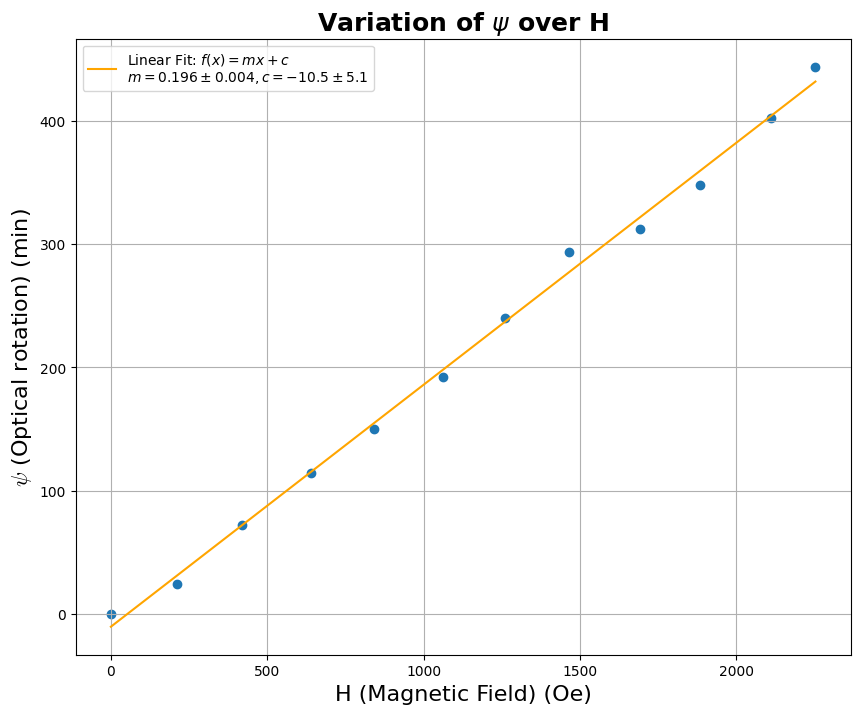

In [16]:
plt.figure(figsize = (10,8))
plt.scatter(magnetic_arr,angle_arr)

params, pcov = curve_fit(stLine,magnetic_arr,angle_arr)
perr = np.sqrt(np.diag(pcov))
plt.plot(
    magnetic_arr,
    stLine(magnetic_arr, *params),
    color='orange',
    label=(
        f"Linear Fit: $f(x)=mx+c$\n"
        f"$m = {params[0]:.3f} \\pm {perr[0]:.3f}, "
        f"c = {params[1]:.1f} \\pm {perr[1]:.1f}$"
    )
)

plt.xlabel("H (Magnetic Field) (Oe)",fontsize = 16)
plt.ylabel(r"$\psi$ (Optical rotation) (min)",math_fontfamily='cm',fontsize = 16)
plt.title(r"Variation of $\psi$ over H",fontsize = 18 , fontweight= 'bold')
plt.legend(loc = "best")
plt.grid(True)
plt.savefig('Plot1.pdf', bbox_inches='tight', dpi=700)
plt.show()

In [24]:
df2 = pd.read_excel('../data/Faraday_data.xlsx',"Sheet2")

In [26]:
print(df2.columns)

Index(['Current ', 'Magnetic field ', 'Intensity (uA)'], dtype='object')


In [28]:
print(df2['Intensity (uA)'])
print(df2['Current '])


0      0.8
1      1.3
2      2.5
3      4.1
4      6.9
5      9.8
6     12.8
7     16.2
8     20.3
9     24.5
10    28.4
Name: Intensity (uA), dtype: float64
0     0.00
1     0.40
2     0.84
3     1.12
4     1.63
5     2.05
6     2.43
7     2.83
8     3.16
9     3.60
10    3.99
Name: Current , dtype: float64


In [29]:
intensity_arr = df2['Intensity (uA)'].to_numpy()
current_arr = df2['Current '].to_numpy()

In [30]:
def sine_sq(x, A, omega, phase, offset):
    return A * (np.sin(omega * x + phase))**2 + offset

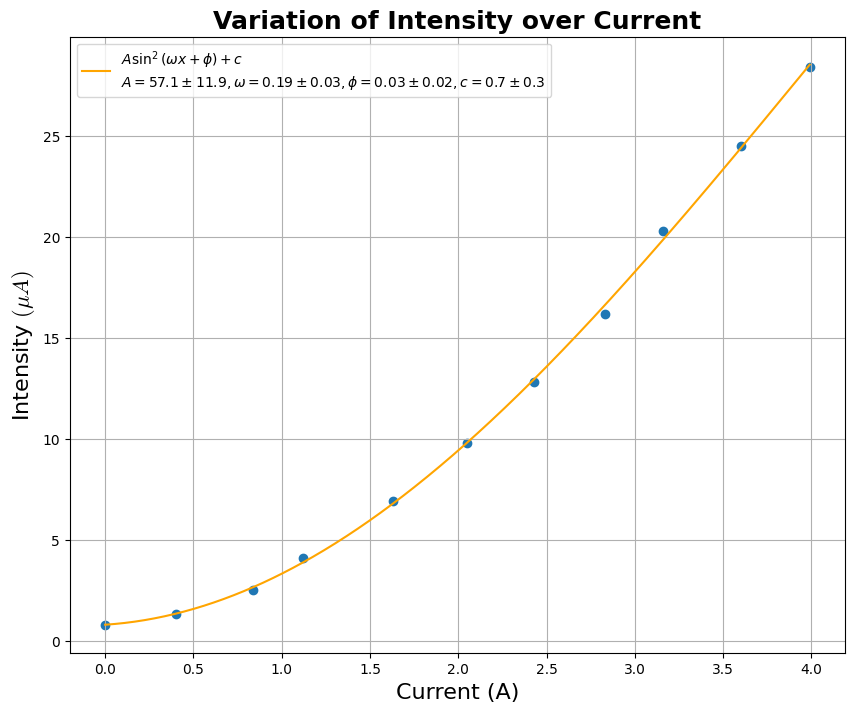

In [41]:
plt.figure(figsize = (10,8))
plt.scatter(current_arr,intensity_arr)

x_range = np.max(current_arr) - np.min(current_arr)
omega_guess = (np.pi / 2) / x_range 

# [Amplitude, Frequency, Phase, Offset]
p0 = [np.max(intensity_arr), omega_guess, 0, np.min(intensity_arr)]

params, pcov = curve_fit(sine_sq,current_arr,intensity_arr,p0=p0)
perr = np.sqrt(np.diag(pcov))

x_fit = np.linspace(np.min(current_arr), np.max(current_arr), 500)

legend_label = (
    rf"$A \sin^2(\omega x + \phi) + c$" + "\n"
    rf"$A = {params[0]:.1f} \pm {perr[0]:.1f}, $"
    rf"$\omega = {params[1]:.2f} \pm {perr[1]:.2f}, $"
    rf"$\phi = {params[2]:.2f} \pm {perr[2]:.2f}, $"
    rf"$c = {params[3]:.1f} \pm {perr[3]:.1f}$"
)

plt.plot(
    x_fit,
    sine_sq(x_fit, *params),
    color='orange',
    label=legend_label
)

plt.xlabel("Current (A)",fontsize = 16)
plt.ylabel(r"Intensity $(\mu A)$",math_fontfamily='cm',fontsize = 16)
plt.title(r"Variation of Intensity over Current",fontsize = 18 , fontweight= 'bold')
plt.legend(loc = "best")
plt.grid(True)
plt.savefig('Plot2.pdf', bbox_inches='tight', dpi=700)
plt.show()